In [1]:
import os
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import emcee
from pandas import DataFrame

In [2]:
POSTERIOR_DIRECTORY = './posteriors_uniform_split_selection'

In [3]:
columns=[
            '$\\Omega_{\\rm m}$',
            '$w_0$',
            '$w_{\\rm a}$',
            '$\\overline{\\lambda}_{\\rm int}$',
            '$\\sigma({\\lambda}_{\\rm int})$',
            '$\\overline{\\gamma}_{\\rm pl}$',
            '$\\sigma({\\gamma}_{\\rm pl})$'
            ]

all_files = os.listdir(POSTERIOR_DIRECTORY)

# load all the posteriors using emcee backend
posteriors = []
dar_energy_FoMs = []
w0_precisions = []
wa_precisions = []
dissimilarities = []
for file in all_files:
    if file.endswith('.h5'):
        backend = emcee.backends.HDFBackend(os.path.join(POSTERIOR_DIRECTORY, file))
        dissimilarity = float(file.split('_')[-1].split('.h5')[0])
        if dissimilarity >= 0.07:
            continue
        dissimilarities.append(dissimilarity)
        posteriors.append(backend)

        samples = backend.get_chain(flat = True,
                            discard=400,
                            thin=10)

        df = DataFrame(samples, columns=columns)

        # compute sigma_w0 and sigma_wa for this posterior
        sigma_w0 = df['$w_0$'].std()
        sigma_wa = df['$w_{\\rm a}$'].std()

        # compute the dark energy figure of merit (FoM) for this posterior
        FoM = 1.0 / (sigma_w0 * sigma_wa)
        dar_energy_FoMs.append(FoM)
        w0_precisions.append(sigma_w0)
        wa_precisions.append(sigma_wa)


# add full sample precision as well
full_sample_backend = emcee.backends.HDFBackend('./posteriors_split_selection/lsst_y10_dissim_full_sample.h5', read_only=True)
full_sample_samples = full_sample_backend.get_chain(flat = True,
                            discard=400,
                            thin=10)
full_sample_df = DataFrame(full_sample_samples, columns=columns)
full_sample_sigma_w0 = full_sample_df['$w_0$'].std()
full_sample_sigma_wa = full_sample_df['$w_{\\rm a}$'].std()
full_sample_FoM = 1.0 / (full_sample_sigma_w0 * full_sample_sigma_wa)

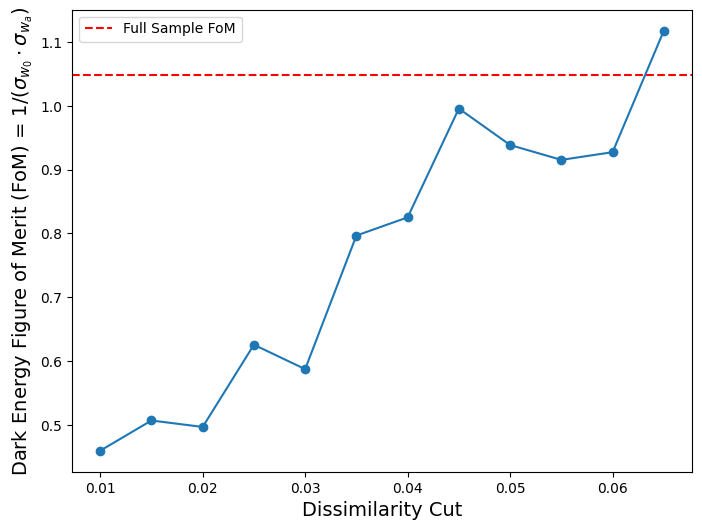

In [4]:
# plot the dark energy figure of merit (FoM) as a function of the dissimilarity
plt.figure(figsize=(8, 6))
plt.plot(dissimilarities, dar_energy_FoMs, marker='o', linestyle='-')

# add a horizontal line for the full sample FoM
plt.axhline(y=full_sample_FoM, color='r', linestyle='--', label='Full Sample FoM')

plt.xlabel('Dissimilarity Cut', fontsize=14)
plt.ylabel('Dark Energy Figure of Merit (FoM) = $1 / (\\sigma_{w_0} \\cdot \\sigma_{w_a})$', fontsize=14)
plt.legend()

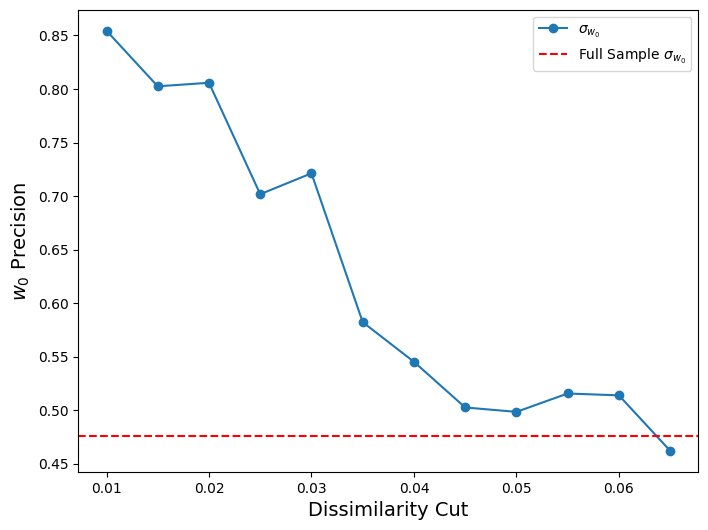

In [5]:
# plot sigma_w0 and sigma_wa as a function of the dissimilarity
plt.figure(figsize=(8, 6))
plt.plot(dissimilarities, w0_precisions, marker='o', linestyle='-', label='$\\sigma_{w_0}$')

# add a horizontal line for the full sample sigma_w0
plt.axhline(y=full_sample_sigma_w0, color='r', linestyle='--', label='Full Sample $\\sigma_{w_0}$')

plt.xlabel('Dissimilarity Cut', fontsize=14)
plt.ylabel('$w_0$ Precision', fontsize=14)
plt.legend()